In [1]:
GPT_CONFIG_124M = {
   "vocab_size": 50257,  # Vocabulary size
   "context_length": 1024,      # Context length
   "emb_dim": 768,       # Embedding dimension
   "n_heads": 12,        # Number of attention heads
   "n_layers": 12,       # Number of layers
   "drop_rate": 0.1,     # Dropout rate
   "qkv_bias": False     # Query-Key-Value bias
}
"""
"vocab_size" refers to a vocabulary of 50,257 words, as used by the
BPE tokenizer from chapter 2.

"context_length" denotes the maximum number of input tokens the
model can handle, via the positional embeddings discussed in chapter 2. 

"emb_dim" represents the embedding size, transforming each token into
a 768-dimensional vector. 

"n_heads" indicates the count of attention heads in the multi-head
attention mechanism, as implemented in chapter 3. 

"n_layers" specifies the number of transformer blocks in the model,
which will be elaborated on in upcoming sections. 

"drop_rate" indicates the intensity of the dropout mechanism (0.1
implies a 10% drop of hidden units) to prevent overfitting, as covered in
chapter 3. 

"qkv_bias" determines whether to include a bias vector in the Linear
layers of the multi-head attention for query, key, and value computations.

We will initially disable this, following the norms of modern LLMs, but will
revisit it in chapter 6 when we load pretrained GPT-2 weights from
OpenAI into our model.

"""

'\n"vocab_size" refers to a vocabulary of 50,257 words, as used by the\nBPE tokenizer from chapter 2.\n\n"context_length" denotes the maximum number of input tokens the\nmodel can handle, via the positional embeddings discussed in chapter 2. \n\n"emb_dim" represents the embedding size, transforming each token into\na 768-dimensional vector. \n\n"n_heads" indicates the count of attention heads in the multi-head\nattention mechanism, as implemented in chapter 3. \n\n"n_layers" specifies the number of transformer blocks in the model,\nwhich will be elaborated on in upcoming sections. \n\n"drop_rate" indicates the intensity of the dropout mechanism (0.1\nimplies a 10% drop of hidden units) to prevent overfitting, as covered in\nchapter 3. \n\n"qkv_bias" determines whether to include a bias vector in the Linear\nlayers of the multi-head attention for query, key, and value computations.\n\nWe will initially disable this, following the norms of modern LLMs, but will\nrevisit it in chapter 6 w

### Normalizing activations with Layer normalization

In [2]:
import torch
import torch.nn as nn

In [3]:
torch.manual_seed(123)
batch_example = torch.randn(2,5)
batch_example

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])

In [4]:
layer = nn.Sequential(nn.Linear(5,6) , nn.ReLU())
out = layer(batch_example)
out

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

In [5]:
# in layer normalisation we normalise across the rows 
mean = out.mean(dim = 1, keepdim=True) # dim = -1 is also true
mean

tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)

In [6]:
var = out.var(dim = -1 , keepdim=True)
var

tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)

In [7]:
class LayerNorm(nn.Module):
    def __init__(self , emb_dim):
        super().__init__()
        self.eps = 1e-5 # eps is just uswd for to prevent division by zero error
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
        # scale and shift are two trainable parameters 

    def forward(self , x):
        mean = x.mean(dim = -1 , keepdim = True)
        var = x.var(dim = - 1 , keepdim = True , unbiased = False) # unbiased is just for stabilisation , IF TRUE then it mean stastical estimation 
        norm_x = (x  - mean) / torch.sqrt(var + self.eps) # self.eps to prevent division by Zero error
        return self.scale * norm_x + self.shift

In [8]:
ln = LayerNorm(6)
outputs_normed = ln(out)

In [9]:
outputs_normed

tensor([[ 0.6745,  1.5470, -0.9549,  0.6431, -0.9549, -0.9549],
        [-0.0207,  0.1228, -1.1913,  1.6619,  0.6186, -1.1913]],
       grad_fn=<AddBackward0>)

In [10]:
outputs_normed.mean(dim=-1 , keepdim=True)

tensor([[0.0000e+00],
        [3.9736e-08]], grad_fn=<MeanBackward1>)

In [11]:
outputs_normed.var(dim = -1 , keepdim=True)

# the mean which is near to 0 and our variance near to 1 proves that it is normalised

tensor([[1.1994],
        [1.1996]], grad_fn=<VarBackward0>)

#### Implementing a Feed Forward network using GeLU activation
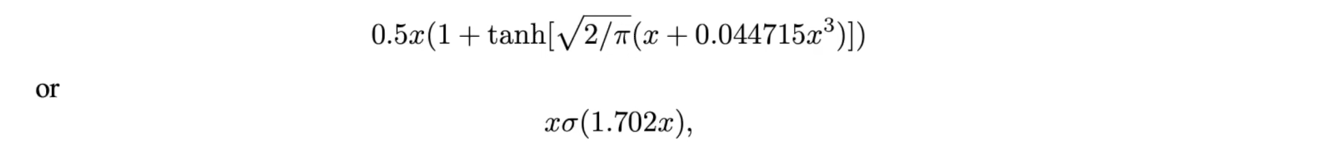
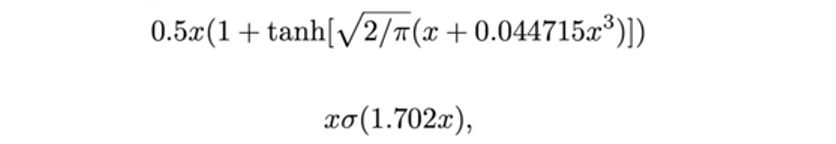

In [12]:
class GeLU(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self , x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x , 3))))

>
    When zip() runs, it grabs the 1st item from both lists and hooks them together. Then it grabs the 2nd item from both lists and hooks them together.Here is exactly how the mapping lands:

    Pair      Item from List 1 (Tensor)     Item from List 2 
    Pair 1       y_gelu                          'GeLU'
    Pair 2       y_relu                          'ReLU'



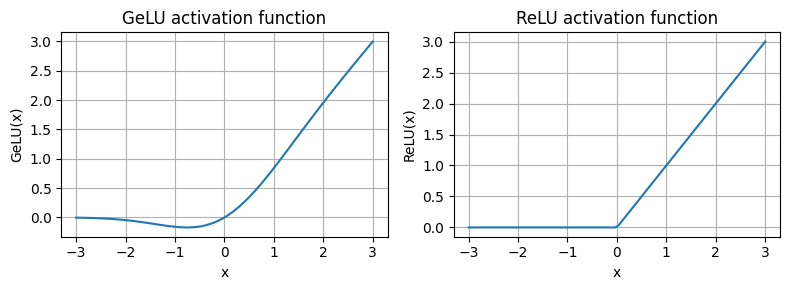

In [13]:
import matplotlib.pyplot as plt
gelu , relu = GeLU() , nn.ReLU()

x = torch.linspace(-3,3,100)
y_gelu , y_relu = gelu(x) , relu(x)

plt.figure(figsize=(8,3))
for i , (y,label) in enumerate(zip([y_gelu , y_relu] , ['GeLU' , 'ReLU']) , 1) : 
    plt.subplot(1,2,i)
    plt.plot(x , y)
    plt.title(f"{label} activation function")
    plt.xlabel('x')
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

- Input: cfg['emb_dim'] (Let's say it's $768$ for GPT-2 Small).
- Hidden Layer: It expands to $4 \times 768 = 3072$.
- Output Layer: It shrinks back down to $768$.

### The Transformer Block Lifecycle

Inside a single Transformer layer, data flows through two main phases: **Tokens Interact (Attention)** and then **Tokens Process (FeedForward)**.

---

#### Step 1: Attention (Tokens Interact)
* **What happens:** Your token embeddings enter the layer and are multiplied by the $Q, K, \text{ and } V$ matrices to calculate attention scores.
* **Outcome:** **Contextual Communication**. Tokens share context with one another (e.g., the word *"bank"* looks at nearby words to figure out if it means a *river bank* or a *money bank*).

#### Step 2: Residual Connection & LayerNorm
* **What happens:** The output of the attention mechanism is added back to the original input (residual connection) and normalized using Layer Normalization.

#### Step 3: FeedForward (Tokens Think Individually) *[The current code which you are in]*
* **What happens:** The normalized output goes directly into your `FeedForward` block ($1 \to 4 \to 1$ linear layers).
* **Crucial Detail:** During this step, there is **zero communication** between tokens. Every single token goes through this block completely independently of the other tokens in the sequence.
* **Outcome:** **Information Processing**. The model processes the newly acquired context it just got from the attention step and updates its internal "knowledge database."

#### Step 4: Final Residual Connection
* **What happens:** The output of your `FeedForward` block is added back to its input (another residual connection) and normalized again before being sent to the next Transformer layer.

In [14]:
class FeedForward(nn.Module):
    def __init__(self , cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg['emb_dim'] , 4 * cfg['emb_dim']),
            GeLU(),
            nn.Linear(4 * cfg['emb_dim'] , cfg['emb_dim']),
        )
    
    def forward(self , x):
        return self.layers(x)

In [15]:
GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

In [16]:
ffn = FeedForward(GPT_CONFIG_124M)

In [17]:
# sample data 
x = torch.randn(2, 3, 768)
ffn(x).shape

torch.Size([2, 3, 768])

In [18]:
ffn.layers

Sequential(
  (0): Linear(in_features=768, out_features=3072, bias=True)
  (1): GeLU()
  (2): Linear(in_features=3072, out_features=768, bias=True)
)

### Adding shortcut connections
>  Originally, shortcut connections were proposed for deep networks in   computer
>    vision (specifically, in residual networks) to mitigate the challenge of vanishing gradients.

>    The vanishing gradient problem refers to the issue where gradients (which guide weight
>    updates during training) become progressively smaller as they propagate backward through
 >   the layers, making it difficult to effectively train earlier layers,

``` STARTING INPUT
               Shape: [1, 2]  (e.g., [[10.0, 20.0]])
                     │
                     ▼
┌──────────────────────────────────────────────┐
│  LAYER 0: nn.Linear(2, 4)                    │
│  Transforms data dimensions from 2 to 4      │
└──────────────────────────────────────────────┘
                     │
                     ▼
               layer_output Shape: [1, 4]
                     │
     ⚡ [1, 2] == [1, 4] ? ── NO!
                     │
                     ▼
            [ SHORTCUT SKIPPED ]
            x = layer_output
                     │
                     ▼
               Current Shape: [1, 4]
                     │
                     ▼
┌──────────────────────────────────────────────┐
│  LAYER 1: nn.Linear(4, 4)                    │
│  Preserves data dimensions at 4              │
└──────────────────────────────────────────────┘
                     │
                     ▼
               layer_output Shape: [1, 4]
                     │
     ⚡ [1, 4] == [1, 4] ? ── YES!
                     │
                     ▼
            [ SHORTCUT APPLIED ]
            x = x + layer_output
                     │
                     ▼
               Current Shape: [1, 4]
                     │
                     ▼
┌──────────────────────────────────────────────┐
│  LAYER 2: nn.Linear(4, 1)                    │
│  Transforms data dimensions from 4 down to 1 │
└──────────────────────────────────────────────┘
                     │
                     ▼
               layer_output Shape: [1, 1]
                     │
     ⚡ [1, 4] == [1, 1] ? ── NO!
                     │
                     ▼
            [ SHORTCUT SKIPPED ]
            x = layer_output
                     │
                     ▼
                FINAL OUTPUT
               Shape: [1, 1]  (e.g., [[0.75]])```

In [22]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self , layer_sizes , use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0] , layer_sizes[1]) , GeLU()),
            nn.Sequential(nn.Linear(layer_sizes[1] , layer_sizes[2]) , GeLU()),
            nn.Sequential(nn.Linear(layer_sizes[2] , layer_sizes[3]) , GeLU()),
            nn.Sequential(nn.Linear(layer_sizes[3] , layer_sizes[4]) , GeLU()),
            nn.Sequential(nn.Linear(layer_sizes[4] , layer_sizes[5]) , GeLU()),

        ])
    
    def forward(self, x):
        for layer in self.layers:
            # compute the output of the current layer
            layer_output = layer(x)
            # check if the shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x
    
def print_gradients(model , x):
    # Forward pass 
    output = model(x)
    target = torch.tensor([[0.]]) # shape = 1,1

    # Calculate loss based on how close the target and output are
    loss = nn.MSELoss()
    loss = loss(output , target)

    # Backward pass to calculate gradient
    loss.backward()

    for name , param in model.named_parameters():
        if 'weight' in name:
            # print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [23]:
layer_sizes = [3,3,3,3,3,1]
sample_input = torch.tensor([[1.0 , 0. , -1.]]) # shape 1,3
torch.manual_seed(123)


In [24]:
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes , use_shortcut=False)
print_gradients(model_without_shortcut , sample_input)

layers.0.0.weight has gradient mean of 0.00020173590746708214
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152042235247791
layers.3.0.weight has gradient mean of 0.0013988739810883999
layers.4.0.weight has gradient mean of 0.00504964729771018


In [26]:
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes , use_shortcut=True)
print_gradients(model_without_shortcut , sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694102346897125
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472


### Connecting att'n and linear layers in Transformer Block
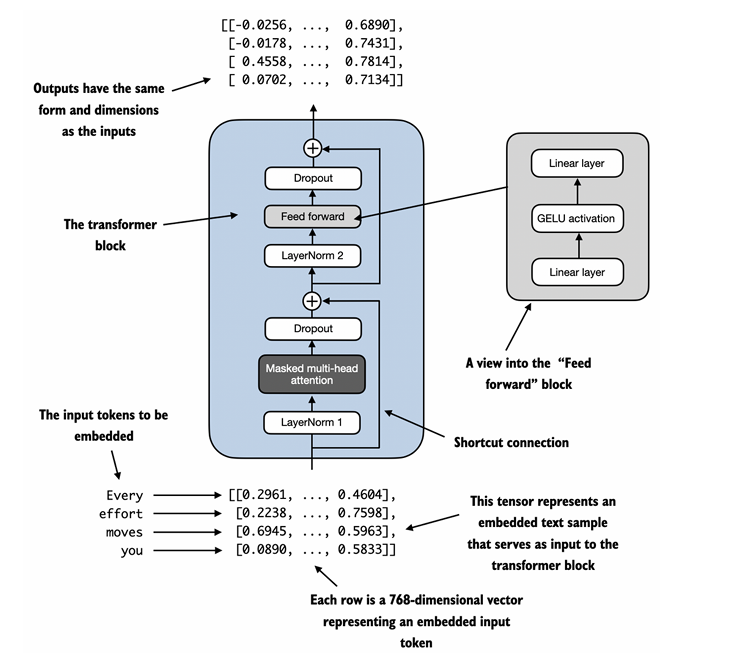

In [27]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in , d_out ,context_length , dropout,num_heads , qkv_bias = False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        """      
            # d_in = 3
            # d_out = 2
            # num_heads = 2
            # head_dim = 1
        """
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in , d_out , bias = qkv_bias)
        self.W_key = nn.Linear(d_in , d_out, bias = qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out , d_out)  # Use a Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask' , torch.triu(torch.ones(context_length , context_length) , diagonal = 1))

    def forward(self, x):
        # say (1,2,6)

        b , num_tokens , d_in = x.shape  # where b -> batch , num_tokens is basically rows , and d_in ->cols or features per token
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # .view() is similar to reshape in numpy ,.view() reshapes a tensor without changing the underlying data.
        keys = keys.view(b , num_tokens, self.num_heads , self.head_dim)
        queries = queries.view(b , num_tokens, self.num_heads , self.head_dim)
        values = values.view(b , num_tokens, self.num_heads , self.head_dim)

        # (1 , 2 , 2, 3 )
        keys = keys.transpose(1,2)   # we want tokens to be under their respective heads thats why transpose 1 and 2 position
        queries = queries.transpose(1,2)
        values = values.transpose(1,2) 
       # (1,2,2,3) x (1,2,2,3)
       #  (2,3) @ (3,2) = (2,2) , (1,2,2,2)
        attn_scores = queries @ keys.transpose(2,3)
        mask_bool = self.mask.bool()[:num_tokens , :num_tokens]

        attn_scores.masked_fill_(mask_bool , -torch.inf)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5 , dim = -1)
        attn_weights = self.dropout(attn_weights)
        context_vec = (attn_weights @ values).transpose(1,2) #  (1,2,2,2) @ (1,2,2,3) = (1,2,2,3)  (batch, heads, seq_len, head_dim)
        # .transpose =  (batch, seq_len, heads, head_dim)  we do this so that .view() can correctly merge in further line
        # see because heads x head_dim = d_out , thats why we arrange them back 
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out) 
        # makes sure tensor data is stored continuously in memory in the correct order. , we can also use reshape()
        context_vec = self.out_proj(context_vec) # out_proj is also a learning param now cause the model wants to use heads effectively
        return context_vec
        

In [29]:
class TransformerBlock(nn.Module):
    def __init__(self , cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in = cfg['emb_dim'],
            d_out = cfg['emb_dim'],
            context_length = cfg['context_length'],
            num_heads = cfg['n_heads'],
            dropout = cfg['drop_rate'],
            qkv_bias = cfg['qkv_bias']
            )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg['emb_dim'])
        self.norm2 = LayerNorm(cfg['emb_dim'])
        self.drop_shortcut = nn.Dropout(cfg['drop_rate'])

    def forward(self , x):
        # shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        # shortcut connection for feed forward network
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

In [30]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

In [31]:
print(x.shape)
print(output.shape)  # the output shape has to be the same as the shape of 
# input block because there will be number of these transformer blocks .

torch.Size([2, 4, 768])
torch.Size([2, 4, 768])


### Coding the GPT model
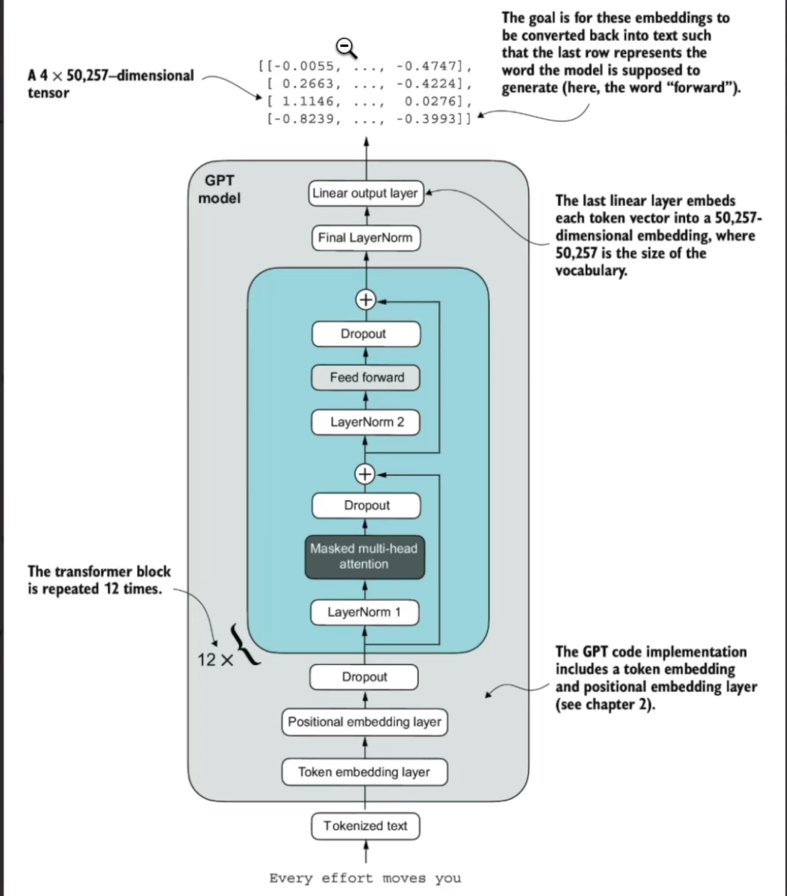


In [37]:
class GPTModel(nn.Module):
    def __init__(self , cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg['vocab_size'] , cfg['emb_dim'])
        self.pos_emb = nn.Embedding(cfg['context_length'] , cfg['emb_dim'])
        self.drop_emb = nn.Dropout(cfg['drop_rate'])

        self.trf_blocks = nn.Sequential(
            * [TransformerBlock(cfg) for _ in range(cfg['n_layers'])]
        )
        self.final_norm = LayerNorm(cfg['emb_dim'])
        self.out_head = nn.Linear(
            cfg['emb_dim'] , cfg['vocab_size'] , bias = False
        )
    
    def forward(self , in_idx):
        batch_size , seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len , device = in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


In [35]:
import tiktoken

tokenizer = tiktoken.get_encoding('gpt2')

batch = []

txt1 = 'Every effort moves you'
txt2 = 'Every day holds a'

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch , dim = 0)
batch

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

In [38]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)

In [39]:
batch.shape

torch.Size([2, 4])

In [40]:
out.shape

torch.Size([2, 4, 50257])

In [ ]:
batch.numel() # number of elements

8

### The 124M Parameter Secret: Weight Tying (Weight Sharing)

When you count parameters manually in PyTorch using `sum(p.numel() for p in model.parameters())`, you get **~163 Million** parameters. Yet, this architecture is famous for being a **124-Million** parameter model. 

---

####  Why is there a ~39M discrepancy?
It comes down to an optimization trick called **Weight Tying** between the entry and exit layers of the model:
1. **`self.tok_emb` (Token Embedding at entry):** Maps token IDs $\to$ vectors. Size: $50,257 \times 768 \approx \mathbf{38.5\text{M}}$
2. **`self.out_head` (LM Head Linear Layer at exit):** Maps vectors back $\to$ token probabilities. Size: $768 \times 50,257 \approx \mathbf{38.5\text{M}}$

In the official GPT-2 architecture, these two layers **share the exact same weight matrix memory pointer** (`model.out_head.weight = model.tok_emb.weight`). 

$$\text{163M (Total Created)} - \text{38.5M (One Shared Layer)} = \mathbf{124.5\text{M Real Parameters}}$$

---

####  Why does this work? (Intuition)



* **Static Dictionary Meanings (Can Be Shared):** The entry and exit layers only deal with the **static dictionary meaning of words** (e.g., mapping the token ID of `"apple"` to its baseline definition vector). Un-embedding at the exit is just the mathematical inverse of embedding at the entry, so they can easily share the same "vocabulary notebook."
* **Dynamic Attention Reasoning (Cannot Be Shared):** The $Q, K, V$ matrices inside the Transformer blocks handle **contextual token interactions** (e.g., figuring out if `"apple"` means a fruit or a tech company in a sentence). Because every layer needs to perform unique, deeper reasoning than the layer before it, attention weights must *never* be shared.

> **TL;DR:** We share weights at the very beginning and very end because they are just a lookup table for **word meanings**. We keep the $Q, K, V$ matrices unique because they handle the **complex attention reasoning**, which is the actual brainpower of the LLM.

In [42]:
total_params = sum(p.numel() for p in model.parameters())
total_params

163009536

In [45]:
print(f'{total_params - model.out_head.weight.numel():,}')

124,412,160


### Generating Text

In [ ]:
def generate_text_simple(model , idx , max_new_tokens , context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[: , -context_size:] # truncate , only first 1024 tokens , just so that model doesn't crash predicting all words
        with torch.no_grad(): # by default pytorch maintains a computaional graph to help in backpropagation used in training a model, by turning off we save some memory thats it cause we just using the model just to check
            logits = model(idx_cond)  #
        logits = logits[: , -1 , :]
        probas = torch.softmax(logits , dim=-1)
        idx_next = torch.argmax(probas , dim = -1 , keepdim=True)
        idx = torch.cat((idx , idx_next) , dim=1)

    return idx

"""
so say i input these three words ->

i am a boy,

so the output vector of 1,4,50257 's 1st row would contain 'am' and 2nd would be 'a' so eventually last row would be next word of boy..
"""

In [57]:
start_context = 'Hello, I am'
encoded = tokenizer.encode(start_context)
print('Encoded :', encoded)

Encoded : [15496, 11, 314, 716]


In [58]:
encoded_tensor = torch.tensor(encoded).unsqueeze(0) # adds a brand-new "Batch Dimension" at index 0 of your tensor.
print('encoded_tensor.shape:' , encoded_tensor.shape) # index 0 is the context of shape dimension like (4) -> (1,4)

encoded_tensor.shape: torch.Size([1, 4])


In [59]:
encoded_tensor

tensor([[15496,    11,   314,   716]])

In [63]:
out = generate_text_simple(model=model,
                           idx = encoded_tensor,
                           max_new_tokens = 6,
                           context_size=GPT_CONFIG_124M['context_length'] )

In [64]:
out

tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 38891, 34320]])

In [ ]:
out = (out.squeeze(0)).tolist()
tokenizer.decode(out) # since its not trained it is speaking rubbish

'Hello, I am Featureiman Byeswick palpMust'